# Supply Genererator Module

The Supply Generator module of the Robin simulator provides a randomized list of services and supply YAML file based on two configuration input files. The generated supply file can be used as an input for the Robin Kernel module.  This notebook is intended to show the functionality of the `SupplyGenerator` class.

## 0. Import Libraries and define file paths

In [1]:
%load_ext autoreload
%load_ext snakeviz
%autoreload 2

import datetime

from robin.plotter.entities import KernelPlotter
from robin.supply.generator.entities import SupplyGenerator
from robin.supply.entities import Supply

from pathlib import Path

In [2]:
supply_config_path = Path("../configs/supply_generator/supply_data.yaml")
generator_config_path = Path("../configs/supply_generator/config.yaml")

# Save paths
generator_save_path = Path(f'../data/generator/supply_dummy.yaml')

## 1. Generate services

The next cell initializes an instance of the `SupplyGenerator` class. Two configuration files must be provided.
- Supply configuration is used as a reference for operational times, RUs, lines, etc.
- Generator configuration file has different parameters such as the range of dates, prices configuration, departure time probability distribution, etc.

In [3]:
seed = 50
SAFETY_GAP = 10

generator = SupplyGenerator.from_yaml(
    path_config_supply=supply_config_path,
    path_config_generator=generator_config_path
)

By calling the `generate()` method, a list of services is obtained based on the provided configuration files. Also, a supply YAML file is saved. It's also possible to specify the number of services to generate for each RU. The services are generated without conflicts by default.

In [4]:
generator.generate(
    n_services=25,
    #n_services_by_tsp={'1': 25, '2': 5},
    output_path=generator_save_path,
    seed=seed,
    progress_bar=True,
    without_conflicts=False
)

print(f'Number of service requests generated: {len(generator.services)}')

Generating services all: 100%|██████████| 25/25 [00:00<00:00, 335.31service/s]

Number of service requests generated: 25


The next cell checks if the generated supply file can be successfully loaded by the Robin Supply module.

In [5]:
supply = Supply.from_yaml(generator_save_path)

print(f'Number of service requests generated: {len(supply.services)}')

Number of service requests generated: 25


## 3. Marey chart from the Plotter module

This cell initializes a `KernelPlotter` object using the generated supply file.

In [6]:
kernel_plotter = KernelPlotter(
    path_config_supply=generator_save_path
)

The Marey chart provides a visual representation of the different services matching de provided date. The method provides a plot for all the branches visited by the provided services.

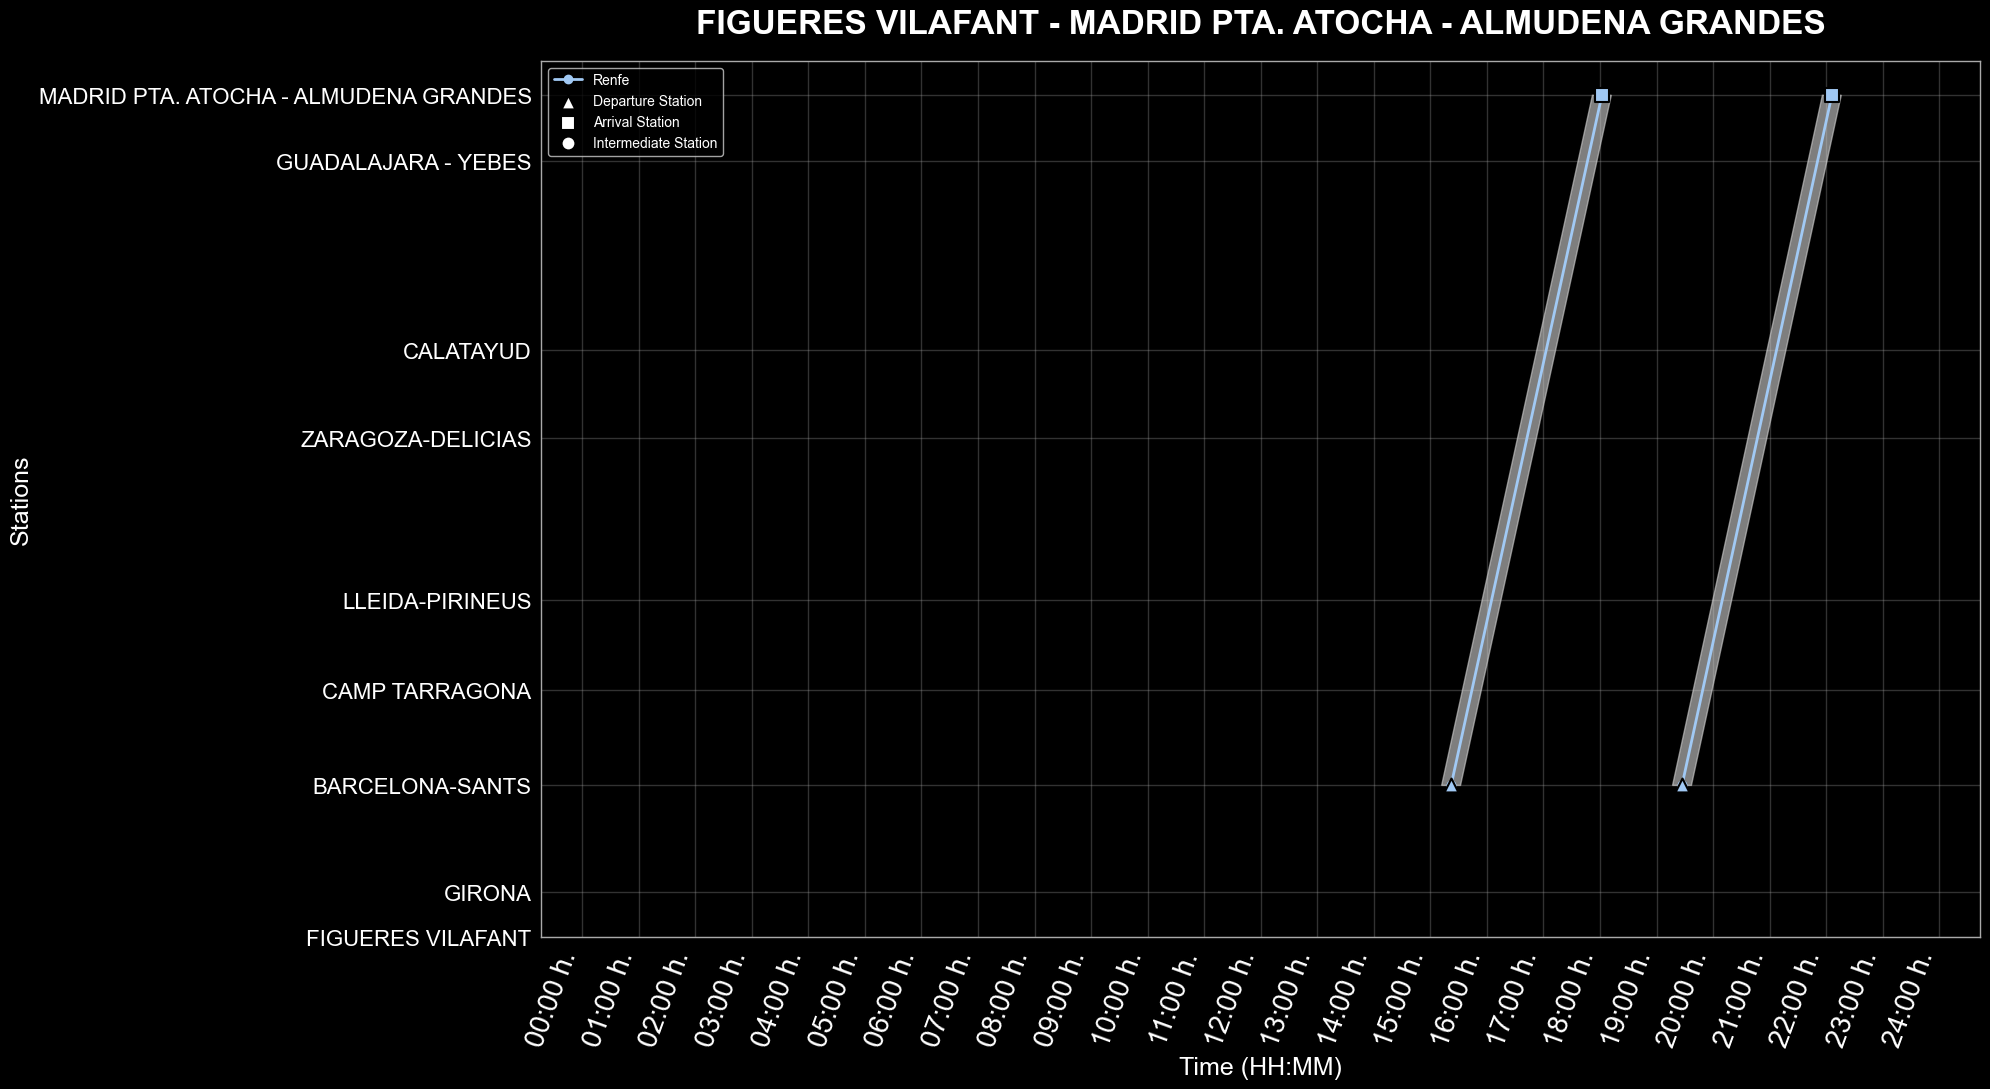

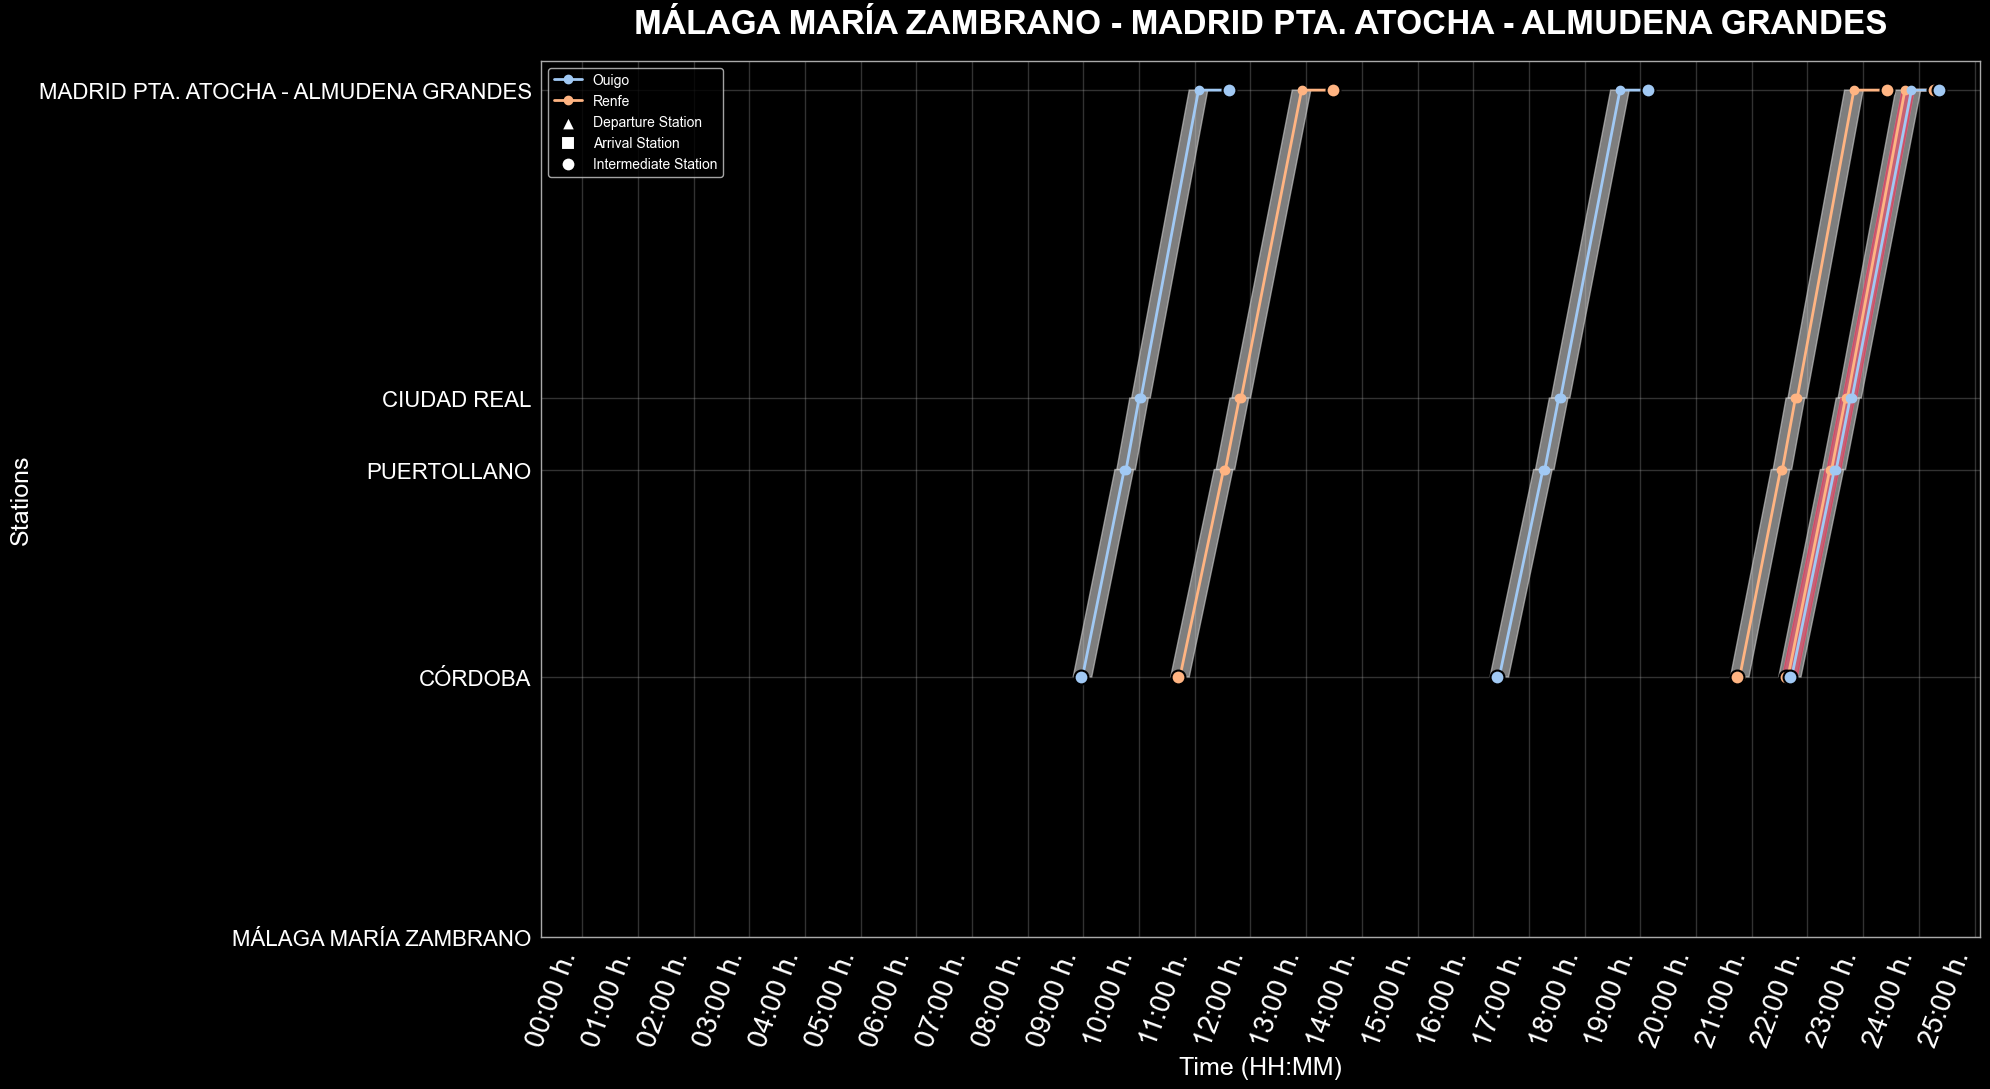

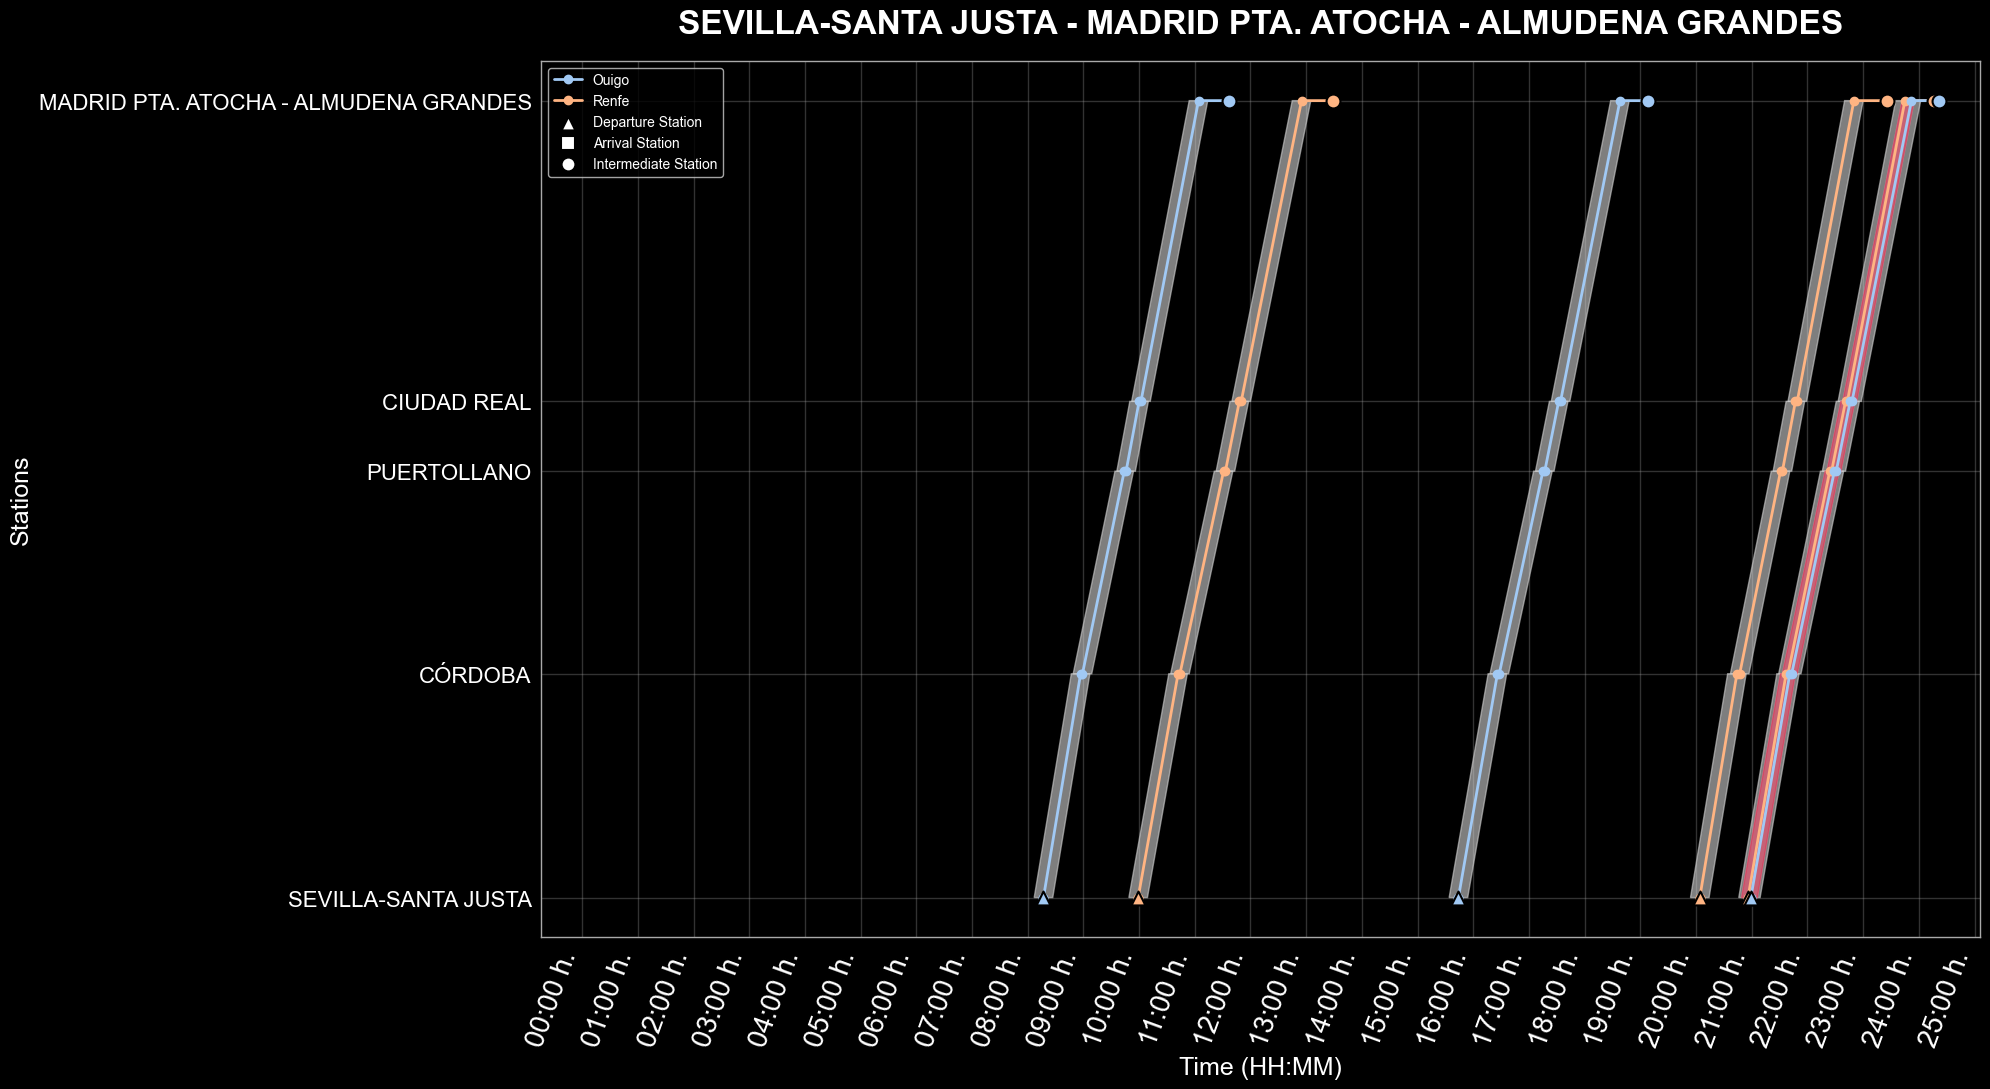

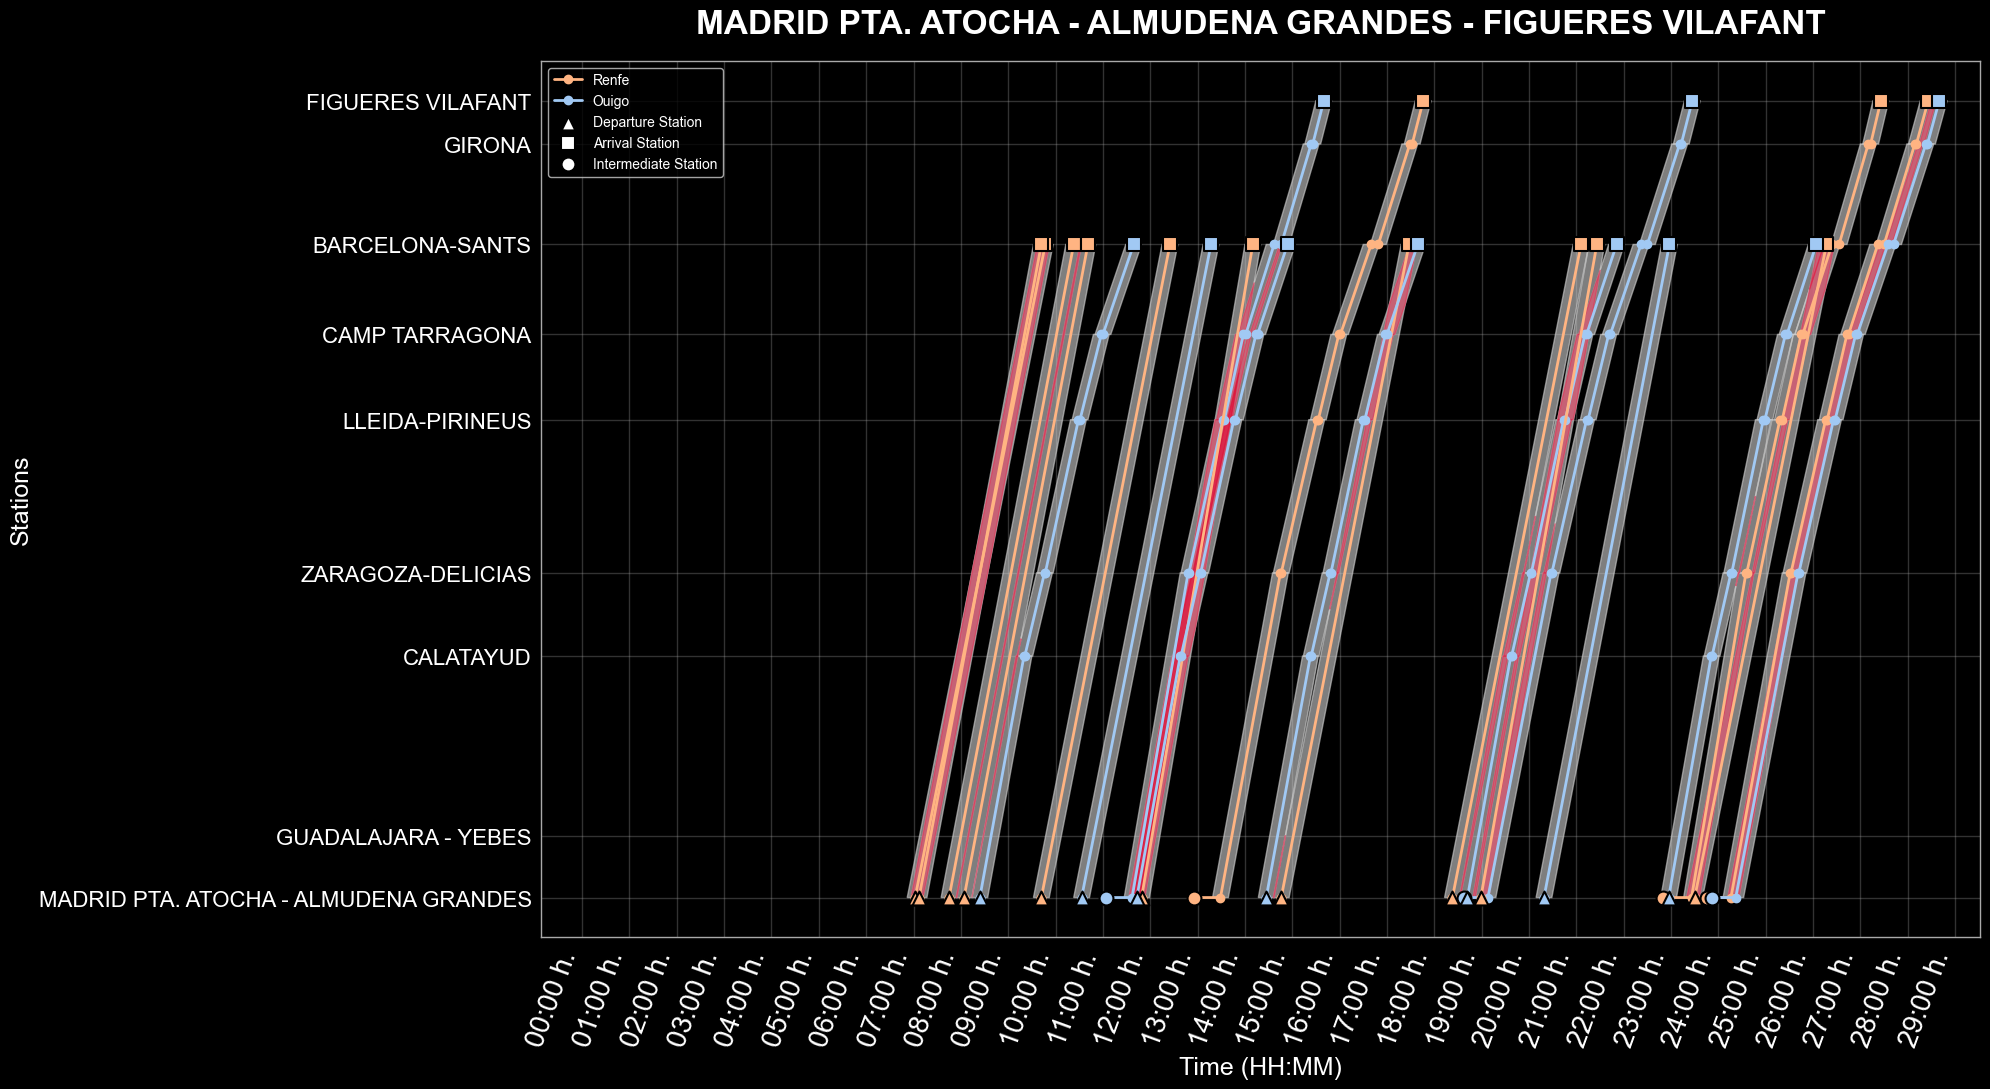

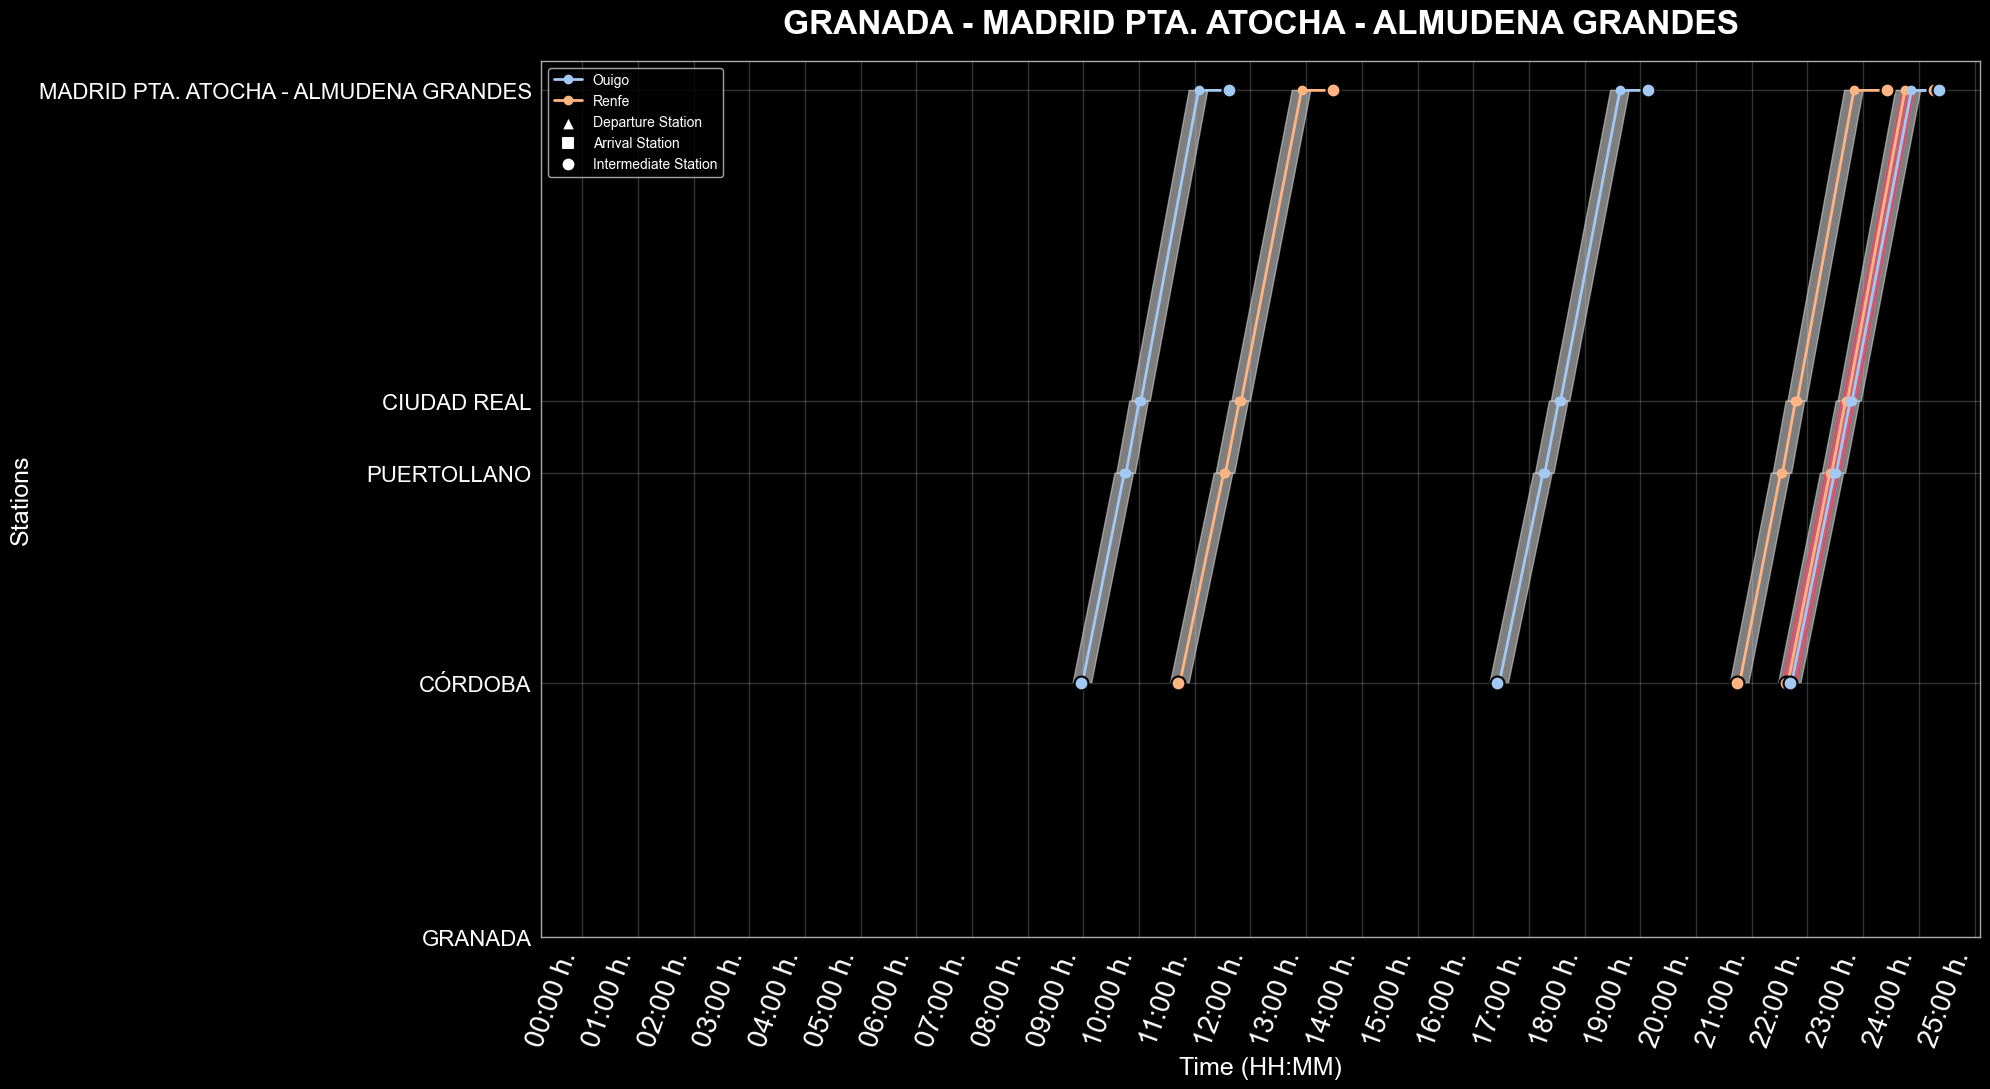

In [7]:
date = datetime.datetime.strptime('2024-06-25', '%Y-%m-%d').date()
kernel_plotter.plot_marey_chart(
    date=date,
    save_path='../reports/figures/'
)

In [10]:
from craft import MealpyTimetabling
from craft import RevenueSimulator

from mealpy.evolutionary_based import GA
from mealpy import IntegerVar

revenue_simulator = RevenueSimulator(supply=supply)
revenue_behaviour = revenue_simulator.simulate_revenue()

mealpy_timetabling = MealpyTimetabling(
    requested_services=supply.services,
    revenue_behavior=revenue_behaviour,
)

lb, ub = zip(*mealpy_timetabling.boundaries.real)

print(f"Boundaries: {lb}, {ub}")
problem = {
    "obj_func": mealpy_timetabling.objective_function,
    "bounds": IntegerVar(lb=lb, ub=ub),
    "minmax": "max",
    "save_population": False
}

optimizer = GA.BaseGA(epoch=50, pop_size=50)
optimizer.solve(problem, seed=29)

2026/02/18 06:27:00 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=50, pop_size=50, pc=0.95, pm=0.025)


Service 00001 schedule: {'60000': [465.0, 465.0], '71801': [623.0, 623.0]}
Service 00002 schedule: {'60000': [582.0, 582.0], '71801': [745.0, 745.0]}
Service 00003 schedule: {'60000': [422.0, 422.0], '71801': [587.0, 587.0]}
Service 00004 schedule: {'60000': [504.0, 504.0], '70600': [560.0, 561.0], '04040': [586.0, 587.0], '78400': [629.0, 631.0], '04104': [658.0, 660.0], '71801': [699.0, 699.0]}
Service 00005 schedule: {'60000': [1219.0, 1219.0], '71801': [1378.0, 1378.0]}
Service 00006 schedule: {'51003': [944.0, 944.0], '50500': [986.0, 988.0], '37300': [1035.0, 1037.0], '37200': [1052.0, 1054.0], '60000': [1118.0, 1148.0], '04040': [1228.0, 1229.0], '78400': [1273.0, 1275.0], '04104': [1301.0, 1303.0], '71801': [1342.0, 1350.0], '79206': [1391.0, 1393.0], '04307': [1407.0, 1407.0]}
Service 00007 schedule: {'71801': [1167.0, 1167.0], '60000': [1326.0, 1326.0]}
Service 00008 schedule: {'51003': [497.0, 497.0], '50500': [537.0, 539.0], '37300': [584.0, 586.0], '37200': [600.0, 602.0],

2026/02/18 06:27:20 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 318.9408515482816, Global best: 318.9408515482816, Runtime: 10.17437 seconds
2026/02/18 06:27:30 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 324.8685977581311, Global best: 324.8685977581311, Runtime: 10.12771 seconds
2026/02/18 06:27:41 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 325.72635673663723, Global best: 325.72635673663723, Runtime: 10.20162 seconds
2026/02/18 06:27:51 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 328.79715253748617, Global best: 328.79715253748617, Runtime: 10.19663 seconds
2026/02/18 06:28:01 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 332.3774392455444, Global best: 332.3774392455444, Runtime: 10.37377 seconds
2026/02/18 06:28:11 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P,

id: 5156, target: Objectives: [368.74574937], Fitness: 368.7457493736643, solution: [ 465.  585.  419.  478.  539.  576.  628.  660. 1221. 1000.  946. 1010.
 1025. 1129. 1234. 1225. 1247. 1355. 1377. 1167.  552.  499.  553.  542.
  688.  731.  781.  783.  884.  869. 1173. 1150. 1165. 1188. 1251. 1450.
 1182. 1243. 1241. 1292. 1358. 1425. 1482. 1551. 1548. 1585.  489.  636.
  641.  685.  696.  810.  891.  936.  922.  994. 1017.  887.  443. 1428.
 1401. 1429. 1449. 1478.  632.  922. 1104. 1263. 1267. 1347. 1353. 1452.
 1510. 1542. 1571. 1641. 1663. 1232. 1270. 1358. 1316. 1443. 1538. 1558.
 1561. 1649. 1683. 1121.  721.  882.  891.  891.  947. 1007.  672.  734.
  786.  782.  822.]

In [11]:
updated_services = mealpy_timetabling.update_supply(path=generator_save_path, solution=mealpy_timetabling.best_solution)

In [12]:
from robin.supply.saver.entities import SupplySaver

SupplySaver(updated_services).to_yaml('../data/results/supply_updated.yaml')

In [13]:
print(supply.services[3].schedule)

{'60000': (datetime.timedelta(seconds=30240), datetime.timedelta(seconds=30240)), '70600': (datetime.timedelta(seconds=33654), datetime.timedelta(seconds=33714)), '04040': (datetime.timedelta(seconds=35184), datetime.timedelta(seconds=35244)), '78400': (datetime.timedelta(seconds=37776), datetime.timedelta(seconds=37896)), '04104': (datetime.timedelta(seconds=39480), datetime.timedelta(seconds=39600)), '71801': (datetime.timedelta(seconds=41952), datetime.timedelta(seconds=41952))}


In [14]:
print(updated_services[3])

Service id: 00004 
	Date of service: 2024-06-25 
	Stops: ['60000', '70600', '04040', '78400', '04104', '71801'] 
	Line times (relative): [(0.0, 0.0), (56.0, 61.0), (86.0, 98.0), (140.0, 150.0), (177.0, 182.0), (221.0, 221.0)] 
	Line times (absolute): [('07:58', '07:58'), ('08:54', '08:59'), ('09:24', '09:36'), ('10:18', '10:28'), ('10:55', '11:00'), ('11:39', '11:39')] 
	Train Service Provider: Ouigo 
	Time Slot: 28680 
	Rolling Stock: Talgo 200 - B 
	Prices: 
		('60000', '70600'): {Elige: 57.33}
		('60000', '04040'): {Elige: 64.6}
		('60000', '78400'): {Elige: 61.04}
		('60000', '04104'): {Elige: 61.84}
		('60000', '71801'): {Elige: 82.34}
		('70600', '04040'): {Elige: 40.11}
		('70600', '78400'): {Elige: 38.09}
		('70600', '04104'): {Elige: 38.79}
		('70600', '71801'): {Elige: 51.66}
		('04040', '78400'): {Elige: 40.97}
		('04040', '04104'): {Elige: 41.86}
		('04040', '71801'): {Elige: 55.69}
		('78400', '04104'): {Elige: 36.49}
		('78400', '71801'): {Elige: 48.42}
		('04104', '71801

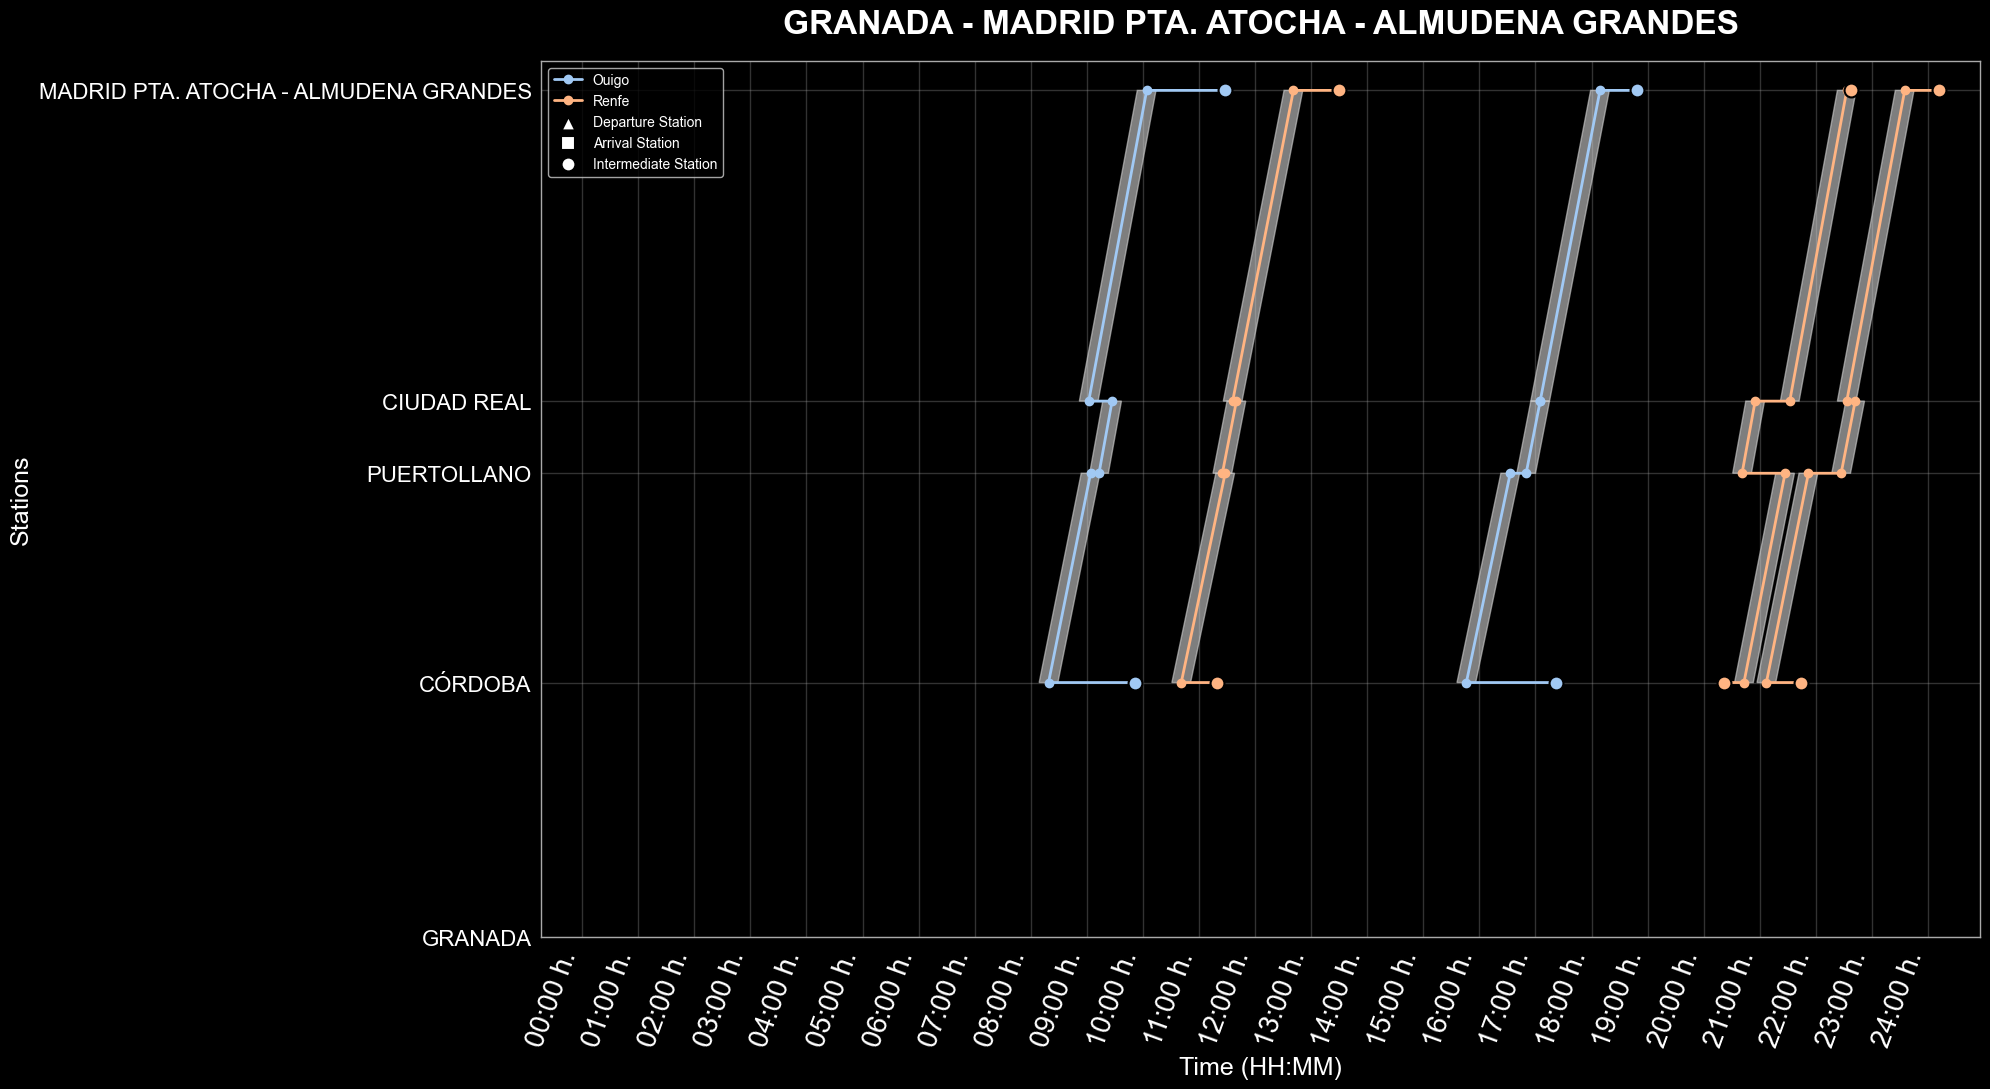

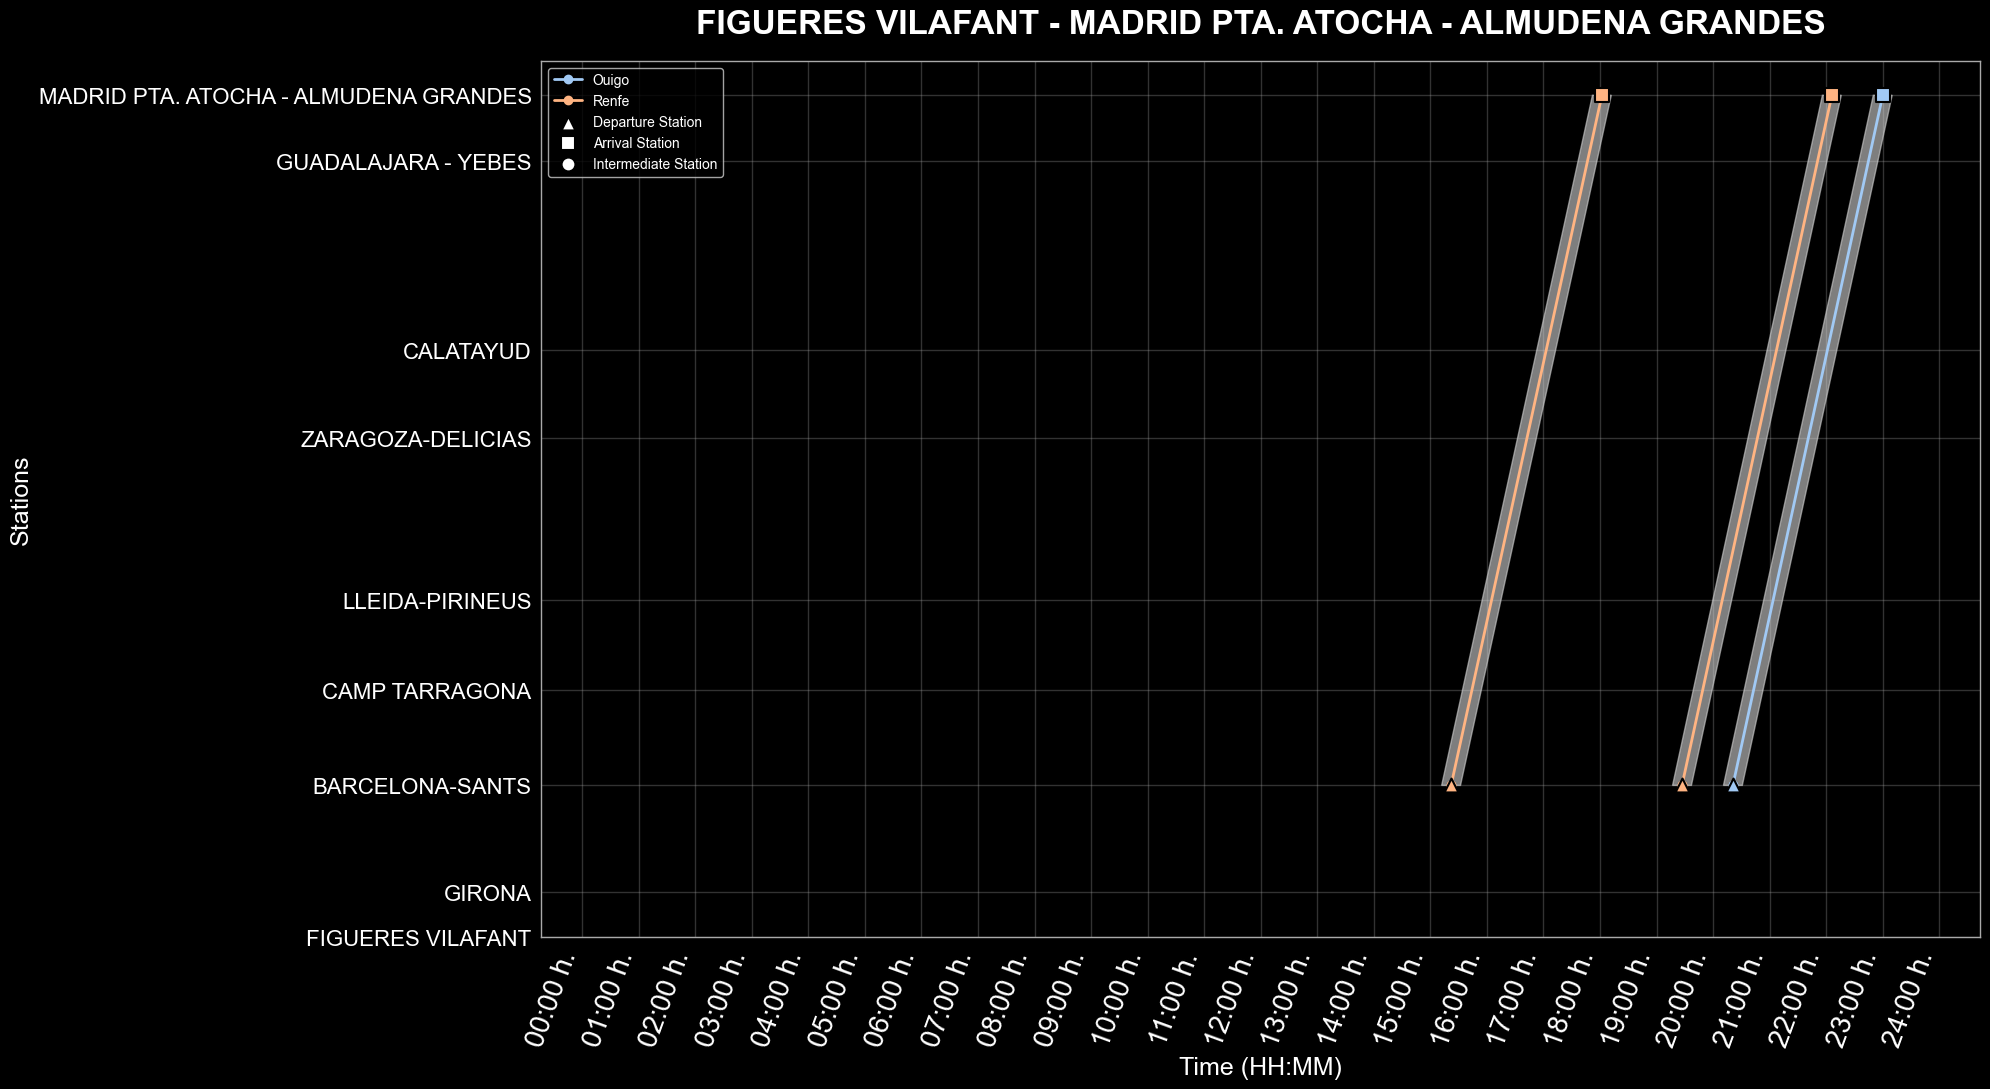

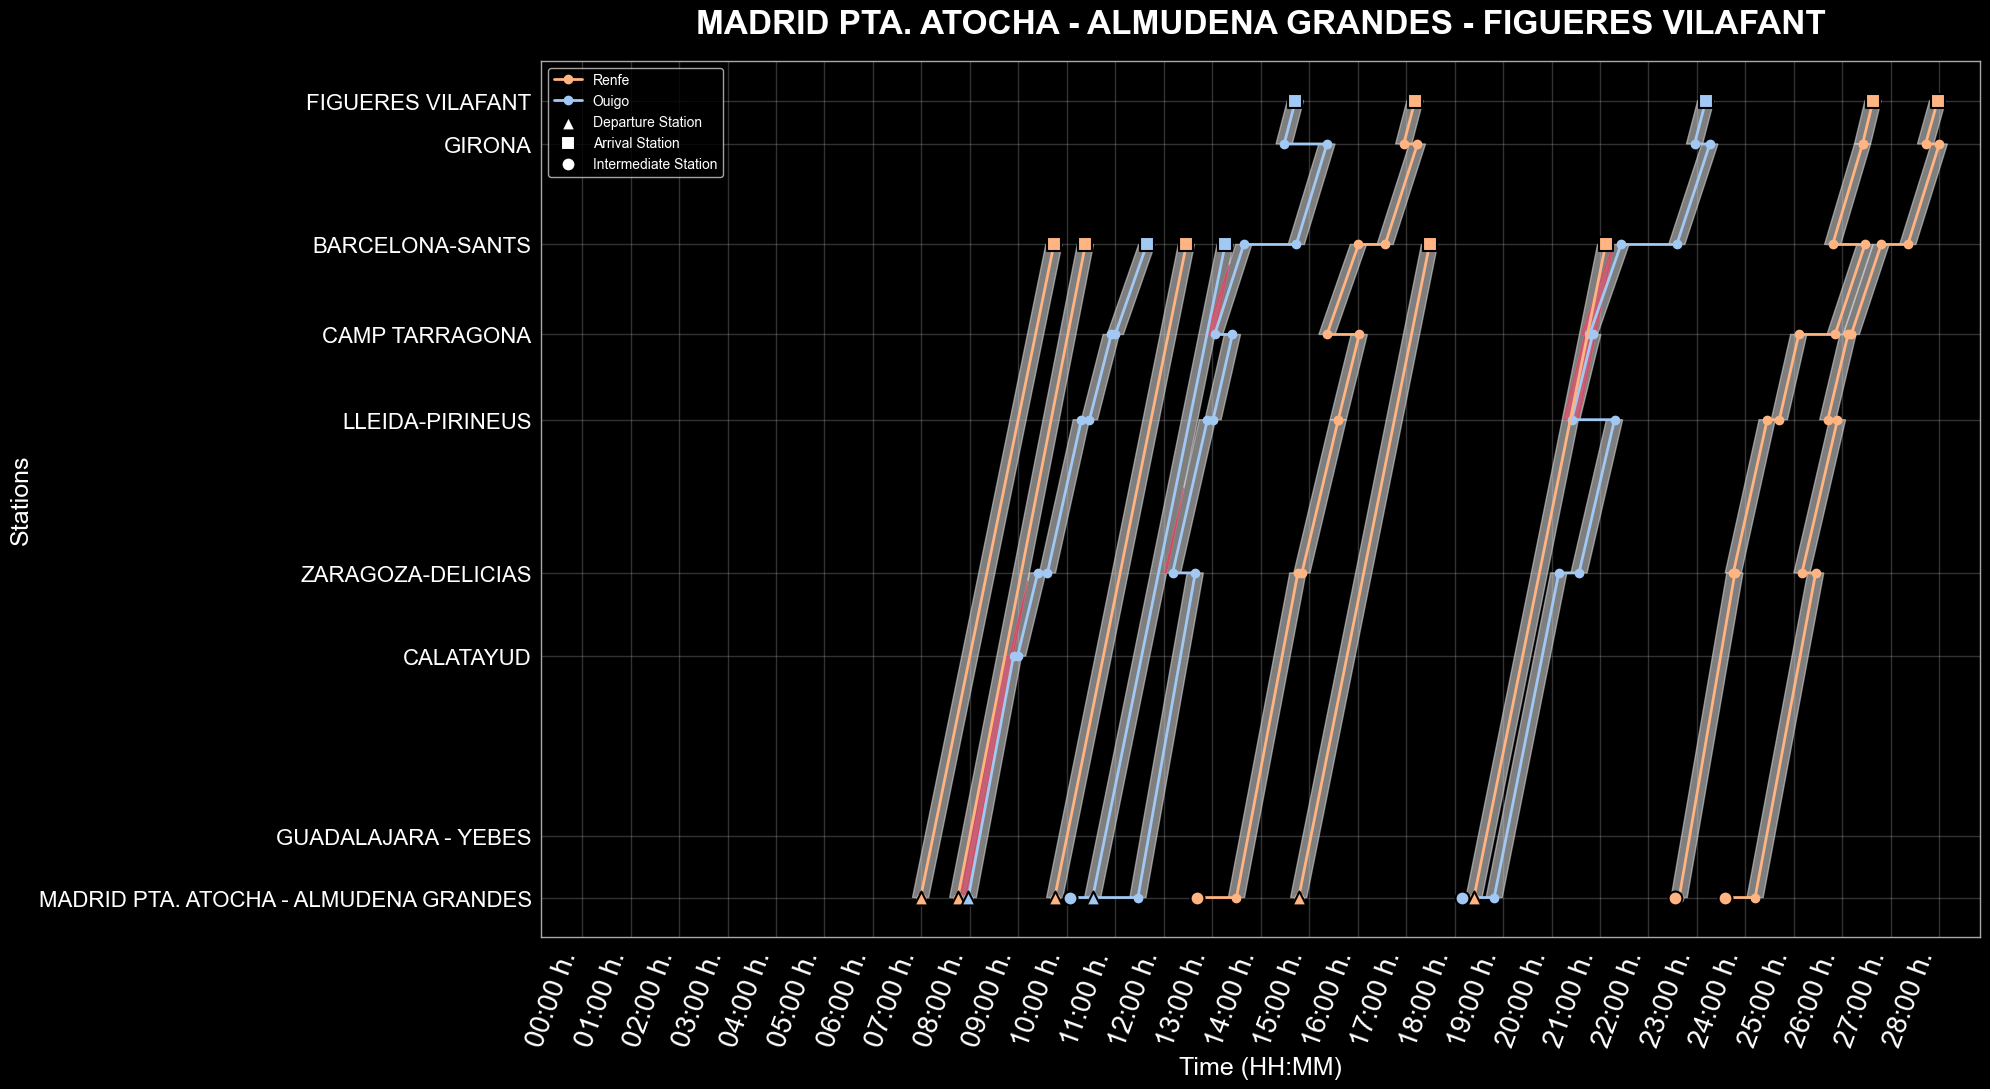

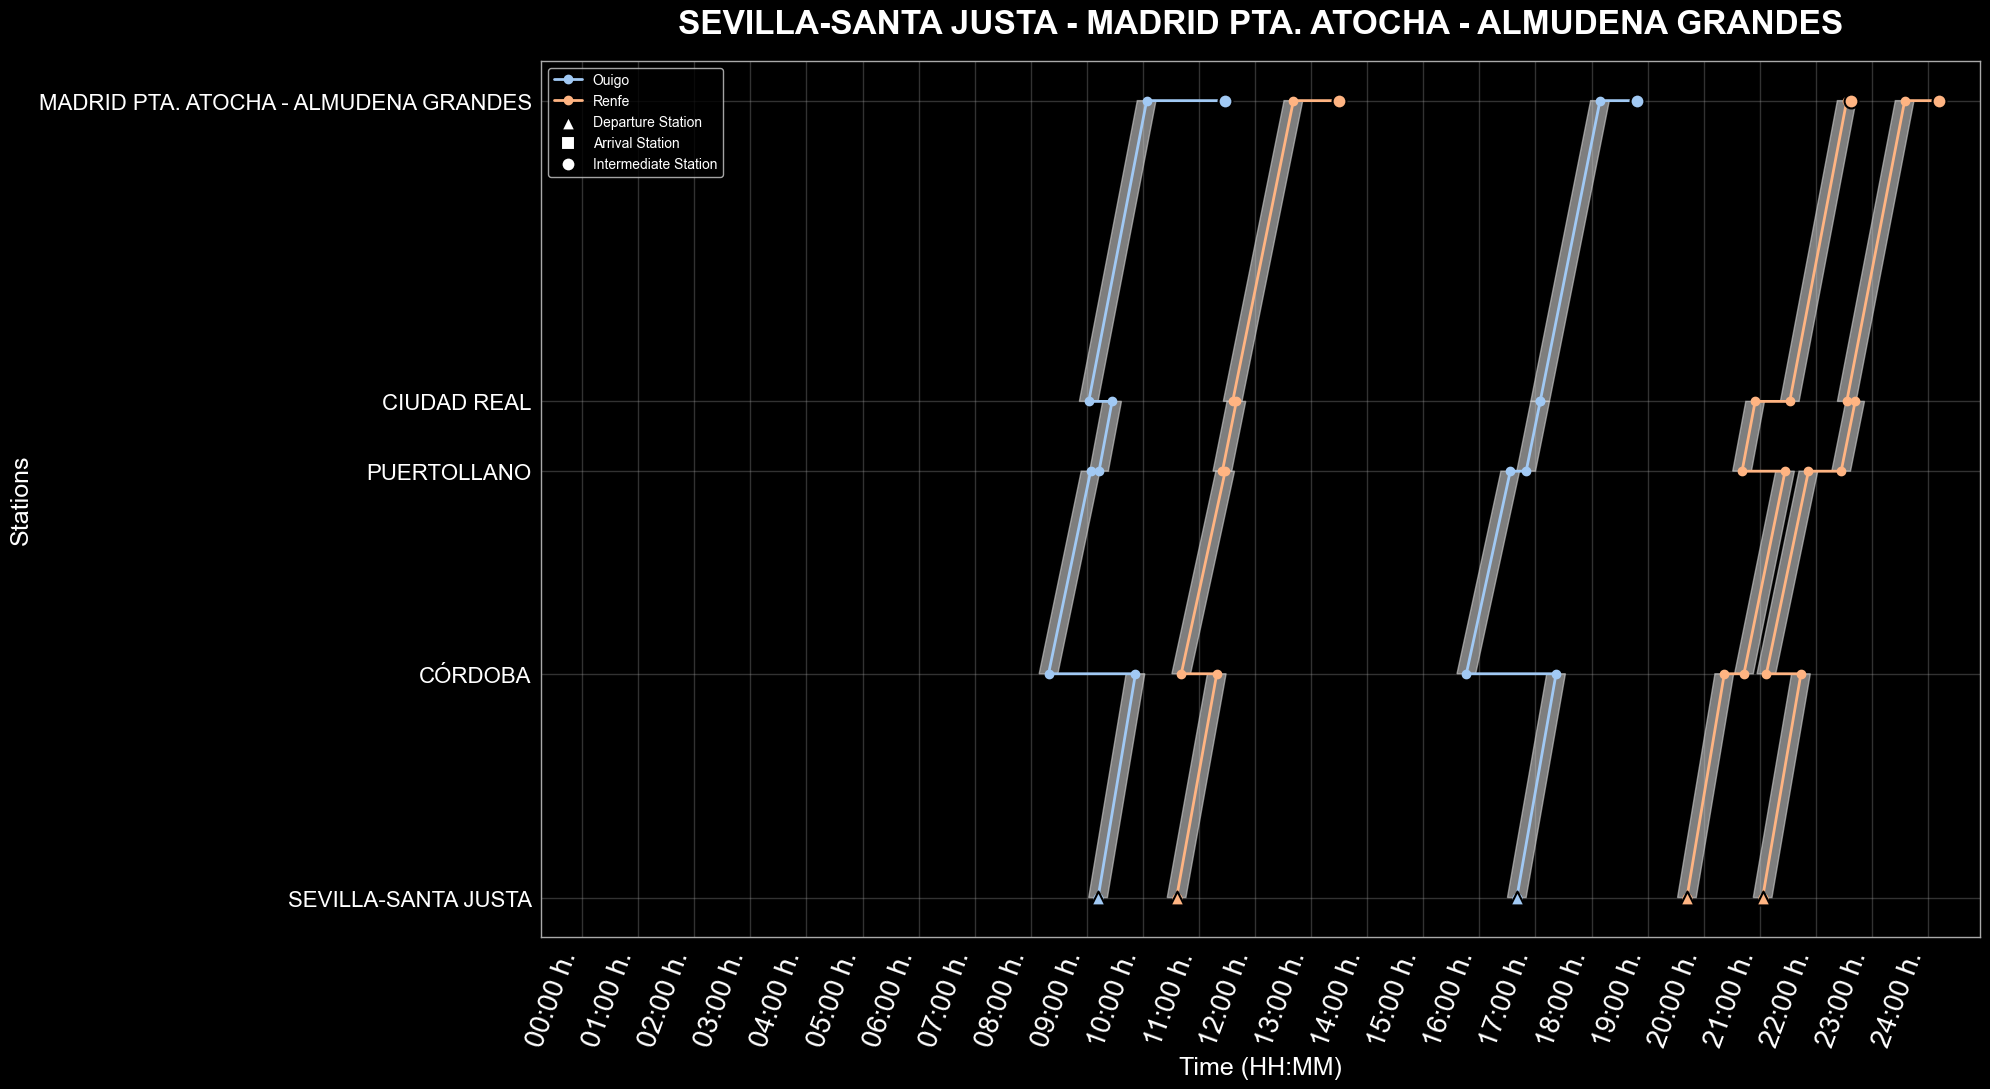

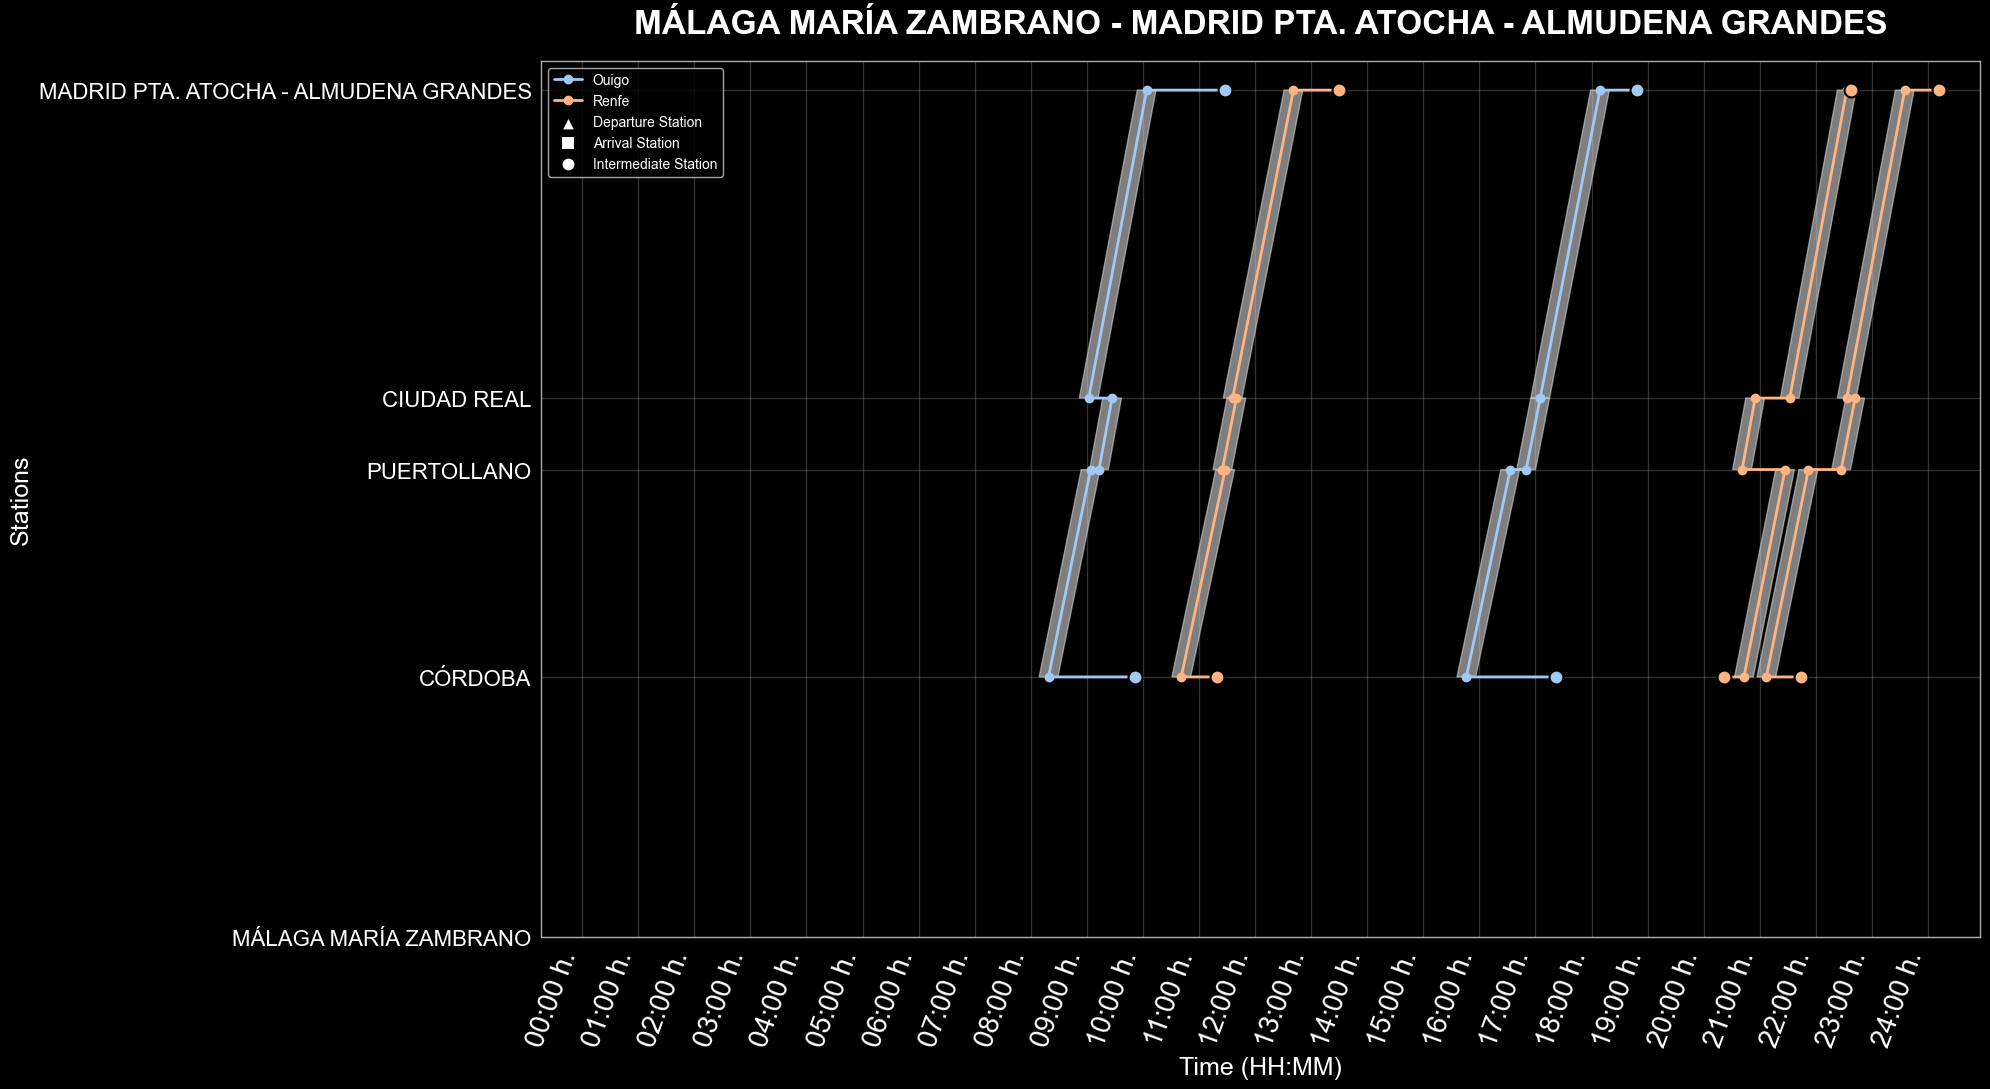

In [15]:
kernel_plotter = KernelPlotter(
    path_config_supply='../data/results/supply_updated.yaml'
)

date = datetime.datetime.strptime('2024-06-25', '%Y-%m-%d').date()
kernel_plotter.plot_marey_chart(
    date=date,
    save_path='../reports/figures/'
)